In [1]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("Packages imported!")

Packages imported!


In the first part of the code, we shall simply iterate through the file and calculate the fragment length of each DNA fragment. The fragment lengths will be stored as a python list, after which we can perform the normalisation operation.

Let $c_l$ be the frequency (count) of fragments with length $l$. Then, the normalised frequency $c'_l$ can be calculated easily. $$c'_l = \frac{c_l}{S}, \text{where } S = \sum_{l = 1}^{l = \infty} c_l$$

Then using matplotlib, the frequency histogram is plotted.

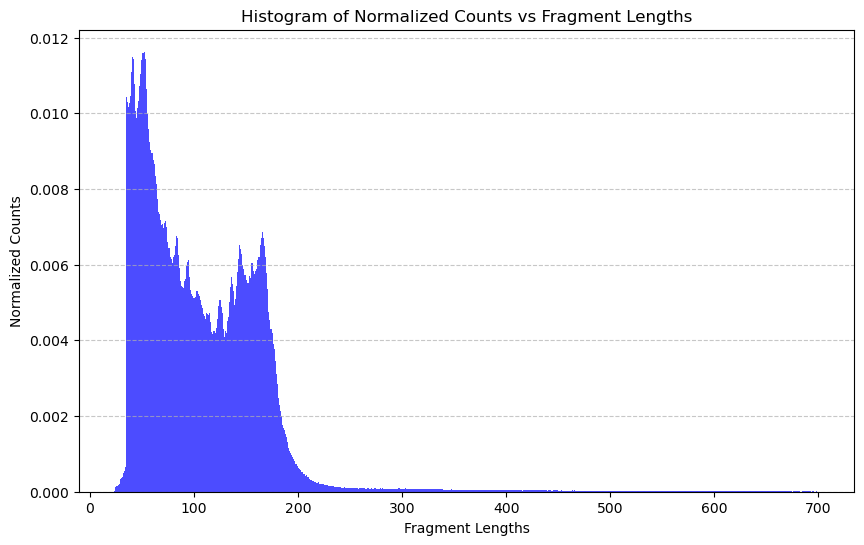

In [3]:
# Read BED file and calculate fragment lengths
fragment_lengths = []

with gzip.open('data/query.bed.gz', 'rt') as f:
    for line in f:
        if line.startswith('#') or line.strip() == '':
            continue
        parts = line.strip().split()
        start = int(parts[1])
        end = int(parts[2])
        fragment_lengths.append(end - start) # As explained in the question

# Count fragment lengths
length_counts = Counter(fragment_lengths)

# Normalize by dividing by the total number of fragments
total_fragments = sum(length_counts.values())
lengths = np.array(list(length_counts.keys()))
counts = np.array(list(length_counts.values()))
normalized_counts = counts / total_fragments

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.bar(lengths, normalized_counts, width=1.0, color='blue', alpha=0.7)
plt.xlabel('Fragment Lengths')
plt.ylabel('Normalized Counts')
plt.title('Histogram of Normalized Counts vs Fragment Lengths')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In this section, we try to rescale the query data to the reference data. This is done by sampling data from the query section in such a way that the the normalised frequency matches the reference. We set a target i.e. the total number of points we want to sample from the query file. The target has been set to 30% to try and match the expected output.

The method of rescaling is to simply sample the minimum of the available and target count at each fragment length.

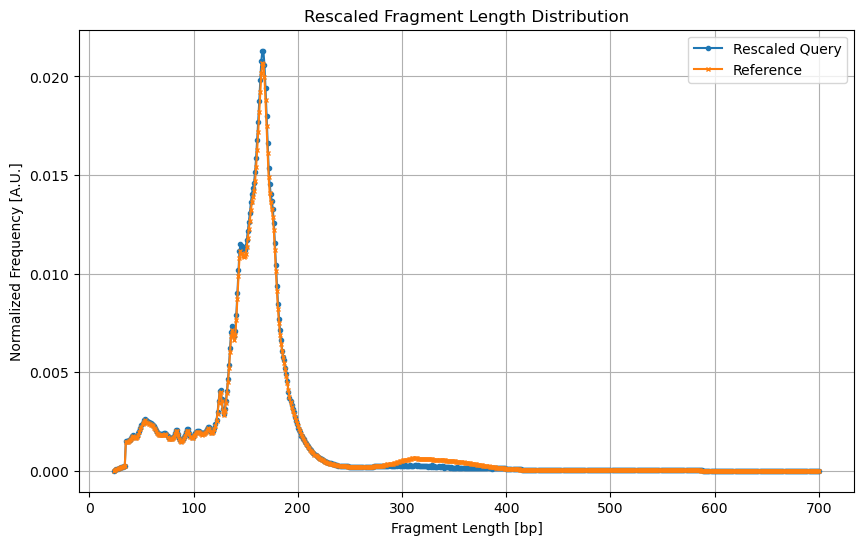

In [4]:
# Load reference histogram
ref_lengths = []
ref_freqs = []

with open('data/reference.hist', 'r') as f:
    for line in f:
        if line.strip() == '':
            continue
        l, freq = map(float, line.strip().split())
        ref_lengths.append(int(l))
        ref_freqs.append(freq)

ref_lengths = np.array(ref_lengths)
ref_freqs = np.array(ref_freqs)

# Make a target number of fragments to sample
# The selection of the target number is arbitrary
# It is set to 30% of the total number of fragments in the query
# This is close to the example in the question

target_total = int(0.3 * len(fragment_lengths))
ref_counts_target = (ref_freqs / ref_freqs.sum()) * target_total
ref_counts_target = ref_counts_target.astype(int)

# Create a lookup for query fragments
fragment_pool = Counter(fragment_lengths)

# Now, resample
rescaled_fragments = []

for l, target_count in zip(ref_lengths, ref_counts_target):
    available = fragment_pool.get(l, 0)
    if available == 0:
        continue
    sample_count = min(available, target_count)
    rescaled_fragments.extend([l] * sample_count)
    fragment_pool[l] -= sample_count  # Decrease availability

# Plot rescaled distribution
rescaled_counter = Counter(rescaled_fragments)
lengths_rescaled = np.array(list(rescaled_counter.keys()))
counts_rescaled = np.array(list(rescaled_counter.values()))
normalized_rescaled_counts = counts_rescaled / counts_rescaled.sum()

# Plotting the rescaled histogram
plt.figure(figsize=(10,6))
plt.plot(lengths_rescaled, normalized_rescaled_counts, 'o-', label='Rescaled Query', markersize=3)
plt.plot(ref_lengths, ref_freqs / ref_freqs.sum(), 'x-', label='Reference', markersize=3)
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Rescaled Fragment Length Distribution')
plt.legend()
plt.grid(True)
plt.show()


Now, we simply combine the two plots by plotting those points on the same axes to get the desired result.

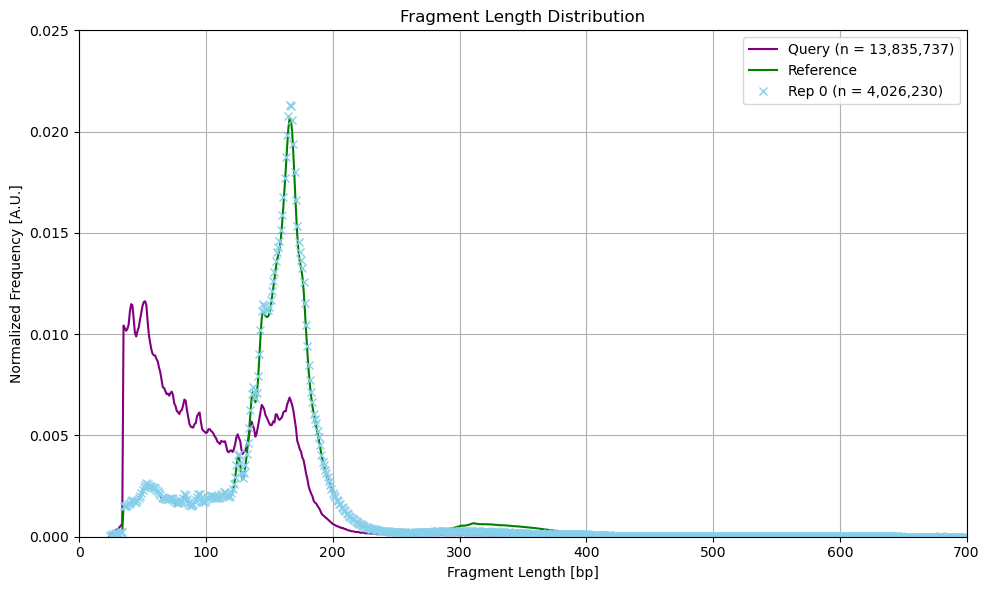

In [5]:
# Combining the plots to get the final desired output

plt.figure(figsize=(10, 6))

# Plot Query
sorted_idx = np.argsort(lengths)
plt.plot(lengths[sorted_idx], normalized_counts[sorted_idx], color='purple', label=f'Query (n = {len(fragment_lengths):,})')

# Plot Reference
sorted_idx_ref = np.argsort(ref_lengths)
plt.plot(ref_lengths[sorted_idx_ref], ref_freqs[sorted_idx_ref] / ref_freqs.sum(), color='green', label='Reference')

# Plot Rescaled
sorted_idx_rescaled = np.argsort(normalized_rescaled_counts)
plt.plot(lengths_rescaled[sorted_idx_rescaled], normalized_rescaled_counts[sorted_idx_rescaled], 
         marker='x', linestyle='None', color='skyblue', label=f'Rep 0 (n = {len(rescaled_fragments):,})')

# Labels and Title
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')
plt.legend()
plt.grid(True)
plt.xlim(0, 700)
plt.ylim(0, 0.025)
plt.tight_layout()
plt.show()
